## Data Analytics: Anime Dataset

In this project, we explore a rich dataset of 18,495 anime titles compiled from Kaggle.

Original Dataset: https://www.kaggle.com/datasets/unibahmad/anime-dataset

Google Drive link: https://drive.google.com/file/d/1EHywBsjjnpBlRH66MOAD3jwQyB7VaZCL/view?usp=sharing

In [91]:
import pandas as pd

anime_df = pd.read_csv('Anime.csv').set_index('Rank')
anime_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18495 entries, 1 to 18495
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             18495 non-null  object 
 1   Japanese_name    7938 non-null   object 
 2   Type             18495 non-null  object 
 3   Episodes         9501 non-null   float64
 4   Studio           12018 non-null  object 
 5   Release_season   4116 non-null   object 
 6   Tags             18095 non-null  object 
 7   Rating           15364 non-null  float64
 8   Release_year     18112 non-null  float64
 9   End_year         2854 non-null   float64
 10  Description      18491 non-null  object 
 11  Content_Warning  1840 non-null   object 
 12  Related_Mange    7627 non-null   object 
 13  Related_anime    10063 non-null  object 
 14  Voice_actors     15309 non-null  object 
 15  staff            13005 non-null  object 
dtypes: float64(4), object(12)
memory usage: 2.4+ MB


### 1. Anime Genres

Parse the comma-separated `Tags` column to identify all unique anime genres. Then build an automated utility that filters the dataset for any chosen genre/tag

In [92]:
# Retrieve all unique tags from the tag column (they separate each other with a coma)
tags_list = anime_df['Tags'].str.split(',').explode().unique()
tags_list

array(['Action', ' Adventure', ' Fantasy', ' Shounen', ' Demons',
       ' Historical', ' Martial Arts', ' Orphans', ' Siblings',
       ' Swordplay', ' Based on a Manga', ' Explicit Violence', 'Drama',
       ' Romance', ' Shoujo', ' Animal Transformation',
       ' Contemporary Fantasy', ' Curse', ' Dysfunctional Families',
       ' Mental Illness', ' Emotional Abuse', '', ' Mature Themes',
       ' Physical Abuse', ' Suicide', ' Violence', ' Domestic Abuse',
       'Fantasy', ' Ancient China', ' Chinese Animation', ' Cultivation',
       ' Xianxia', ' Based on a Web Novel', ' Drama', ' Mystery',
       ' Conspiracy', ' Death of a Loved One', ' Military',
       ' Animal Abuse', ' Horror', ' Dark Fantasy', ' Isolated Society',
       ' Outside World', ' Post-apocalyptic', ' Cannibalism',
       ' Exorcists', ' Monsters', ' School Life', ' Supernatural', ' War',
       ' Trains', 'Shounen', ' Sports', ' Animeism', ' School Club',
       ' Tournaments', ' Volleyball', ' Body Swapping',

In [93]:
import os

def save_anime_by_tag(tag_name, df=anime_df):
    # Create the 'tags' folder if it doesn't exist yet
    os.makedirs('tags', exist_ok=True)

    # Filter the dataframe for the specified tag
    filtered_df = df[df['Tags'].str.contains(tag_name, case=False, na=False)]

    # Generate a clean filename inside the 'tags' directory
    filename = f"tags/{tag_name.lower().replace(' ', '_')}.csv"

    # Save to CSV
    filtered_df.to_csv(filename, index=False)
    print(f"Saved as {filename}")

# Example usage:
save_anime_by_tag('Action')
save_anime_by_tag('Shounen')
save_anime_by_tag('Fantasy')
save_anime_by_tag('Romance')
save_anime_by_tag('Slice of Life')

Saved as tags/action.csv
Saved as tags/shounen.csv
Saved as tags/fantasy.csv
Saved as tags/romance.csv
Saved as tags/slice_of_life.csv


## 2. Characters from the anime

Extracts the character lists and their corresponding Japanese or English voice actors (Seiyuu).

Since this information is stored as packed text pairs in the `Voice_actors` column, we implement parser logic to restructure it into a clean, searchable DataFrame format for any queried series.

In [94]:
def parse_characters_and_voice_actors(anime_title, df=anime_df):
    # Find the specific anime row
    anime_row = df[df['Name'].str.lower() == anime_title.lower()]
    if anime_row.empty:
        # Try a partial match if exact match is not found
        anime_row = df[df['Name'].str.contains(anime_title, case=False, na=False)]

    if anime_row.empty:
        print(f"No anime found matching '{anime_title}'")
        return None

    # Use the first match found
    target_anime = anime_row.iloc[0]
    va_string = target_anime['Voice_actors']

    if pd.isna(va_string):
        print(f"No voice actor information available for '{target_anime['Name']}'")
        return None

    # Parse the 'Character : Voice Actor' pairs separated by commas
    pairs = [pair.strip() for pair in va_string.split(',') if pair.strip()]

    parsed_data = []
    for pair in pairs:
        if ':' in pair:
            char, actor = pair.split(':', 1)
            parsed_data.append({
                'Character': char.strip(),
                'Voice Actor': actor.strip()
            })
        else:
            parsed_data.append({
                'Character': pair.strip(),
                'Voice Actor': 'Unknown'
            })

    parsed_df = pd.DataFrame(parsed_data)
    print(f"Characters & Voice Actors for: {target_anime['Name']}")
    return parsed_df

# Example usage: display characters for Demon Slayer
display(parse_characters_and_voice_actors('Demon Slayer'))

Characters & Voice Actors for: Demon Slayer: Kimetsu no Yaiba - Entertainment District Arc


,Character,Voice Actor
0,Inosuke Hashibira,Yoshitsugu Matsuoka
1,Nezuko Kamado,Akari Kitou
2,Tanjirou Kamado,Natsuki Hanae
3,Zenitsu Agatsuma,Hiro Shimono
4,Daki,Miyuki Sawashiro
5,Tengen Uzui,Katsuyuki Konishi
6,Akaza,Akira Ishida
7,Amane Ubuyashiki,Unknown
8,Koyoharu Gotouge\nOriginal Creator,Unknown
9,Haruo Sotozaki\nDirector,Unknown


In [95]:
display(parse_characters_and_voice_actors('Sword Art Online'))

Characters & Voice Actors for: Sword Art Online


,Character,Voice Actor
0,Asuna Yuuki,Haruka Tomatsu
1,Kirito,Yoshitsugu Matsuoka
2,Suguha Kirigaya,Ayana Taketatsu
3,Agil,Hiroki Yasumoto
4,Akihiko Kayaba,Kouichi Yamadera
5,Heathcliff,Tooru Ookawa
6,Klein,Hiroaki Hirata
7,Nobuyuki Sugou,Takehito Koyasu
8,Tomohiko Itou\nDirector,Unknown
9,Yuki Kajiura\nMusic,Unknown


In [96]:
display(parse_characters_and_voice_actors('Attack on Titan'))

Characters & Voice Actors for: Attack on Titan


,Character,Voice Actor
0,Armin Arlelt,Marina Inoue
1,Eren Jaeger,Yuuki Kaji
2,Mikasa Ackerman,Yui Ishikawa
3,Annie Leonhart,Yu Shimamura
4,Bertholdt Hoover,Tomohisa Hashizume
5,Conny Springer,Hiro Shimono
6,Dot Pyxis,Masahiko Tanaka
7,Eld Gin,Susumu Chiba
8,Hajime Isayama\nOriginal Creator,Unknown
9,Tetsurou Araki\nDirector & Episode Director & ...,Unknown


In [97]:
display(parse_characters_and_voice_actors('DanDaDan'))

No anime found matching 'DanDaDan'


None

In [98]:
display(parse_characters_and_voice_actors('Gintama'))

Characters & Voice Actors for: Gintama


,Character,Voice Actor
0,Gintoki Sakata,Tomokazu Sugita
1,Kagura,Rie Kugimiya
2,Shinpachi Shimura,Daisuke Sakaguchi
3,Ayumu Tojo,Kouji Yusa
4,Catherine,Yuu Sugimoto
5,Elizabeth,Misaki Sekiyama
6,Isao Kondo,Susumu Chiba
7,Kamui,Satoshi Hino
8,Hideaki Sorachi\nOriginal Creator,Unknown
9,Shinji Takamatsu\nDirector,Unknown


In [99]:
display(parse_characters_and_voice_actors('Black Clover'))

Characters & Voice Actors for: Black Clover


,Character,Voice Actor
0,Asta,Nao Fujita
1,Noelle Silva,Kana Yuuki
2,Yuno,Nobunaga Shimazaki
3,Charmy Pappitson,Kiyono Yasuno
4,Finral Roulacase,Jun Fukuyama
5,Gauche Adla,Satoshi Hino
6,Gordon Agrippa,Kenichirou Matsuda
7,Grey,Minami Takahashi
8,Yuuki Tabata\nOriginal Creator,Unknown
9,Tatsuya Yoshihara\nDirector & Chief Director,Unknown


In [100]:
display(parse_characters_and_voice_actors('One Piece'))

Characters & Voice Actors for: One Piece


,Character,Voice Actor
0,Brook,Choo
1,Franky,Junko Noda
2,Monkey D. Luffy,Mayumi Tanaka
3,Nami,Wakana Yamazaki
4,Robin Nico,Yuuko Kobayashi
5,Sanji,Ikue Ootani
6,Tony Tony Chopper,Ikue Ootani
7,Usopp,Kappei Yamaguchi
8,Eiichiro Oda\nOriginal Creator,Unknown
9,Tatsuya Nagamine\nDirector,Unknown


In [101]:
display(parse_characters_and_voice_actors('Naruto'))

Characters & Voice Actors for: Naruto


,Character,Voice Actor
0,Kakashi Hatake,Kazuhiko Inoue
1,Naruto Uzumaki,Junko Takeuchi
2,Sakura Haruno,Chie Nakamura
3,Sasuke Uchiha,Noriaki Sugiyama
4,Asuma Sarutobi,Juurouta Kosugi
5,Choji Akimichi,Kentarou Itou
6,Gaara,Akira Ishida
7,Hinata Hyuga,Nana Mizuki
8,Masashi Kishimoto\nOriginal Creator,Unknown
9,Hayato Date\nDirector,Unknown


In [102]:
display(parse_characters_and_voice_actors('Fairy Tail'))

Characters & Voice Actors for: Fairy Tail


,Character,Voice Actor
0,Charle,Yui Horie
1,Erza Scarlet,Sayaka Oohara
2,Gray Fullbuster,Eri Kitamura
3,Happy,Rie Kugimiya
4,Lucy Heartfilia,Aya Hirano
5,Natsu Dragneel,Mako
6,Wendy Marvell,Satomi Satou
7,Bickslow,Yoshihisa Kawahara
8,Hiro Mashima\nOriginal Creator,Unknown
9,Shinji Ishihira\nDirector & Storyboard,Unknown


In [103]:
display(parse_characters_and_voice_actors('Bleach'))

Characters & Voice Actors for: Bleach


,Character,Voice Actor
0,Ichigo Kurosaki,Masakazu Morita
1,Orihime Inoue,Yuki Matsuoka
2,Renji Abarai,Kentarou Itou
3,Rukia Kuchiki,Fumiko Orikasa
4,Uryu Ishida,Takako Honda
5,Yasutora Sado,Hiroki Yasumoto
6,Byakuya Kuchiki,Ryotaro Okiayu
7,Coyote Starrk,Rikiya Koyama
8,Tite Kubo\nOriginal Creator,Unknown
9,Noriyuki Abe\nDirector,Unknown


In [104]:
display(parse_characters_and_voice_actors('Toaru'))

Characters & Voice Actors for: Toaru Kagaku no Railgun: Entenka no Satsuei Model mo Raku Ja Arimasen wa ne


,Character,Voice Actor
0,Kazari Uiharu,Aki Toyosaki
1,Kuroko Shirai,Satomi Arai
2,Mikoto Misaka,Rina Satou
3,Ruiko Saten,Kanae Itou
4,Mitsuko Kongo,Minako Kotobuki
5,Ekaterina,Unknown
6,Maiko Iuchi\nMusic,Unknown
7,Yuuichi Tanaka\nCharacter Design,Unknown


In [105]:
display(parse_characters_and_voice_actors('Akame'))

Characters & Voice Actors for: Akame ga Kill!


,Character,Voice Actor
0,Akame,Sora Amamiya
1,Tatsumi,Soma Saito
2,Bols,Eiji Takemoto
3,Bulat,Katsuyuki Konishi
4,Chelsea,Kaori Nazuka
5,Esdeath,Satomi Akesaka
6,Honest,Kouji Ishii
7,Kurome,Ayaka Oohashi
8,Takahiro\nOriginal Creator,Unknown
9,Tomoki Kobayashi\nDirector,Unknown


In [106]:
display(parse_characters_and_voice_actors('Date'))

Characters & Voice Actors for: Date a Live: Encore OVA


,Character,Voice Actor
0,Kurumi Tokisaki,Asami Sanada
1,Shido Itsuka,Nobunaga Shimazaki
2,Kotori Itsuka,Ayana Taketatsu
3,Tohka Yatogami,Marina Inoue
4,Yoshino,Iori Nomizu


In [107]:
display(parse_characters_and_voice_actors('Hero'))

Characters & Voice Actors for: My Hero Academia 3


,Character,Voice Actor
0,All Might,Kenta Miyake
1,Izuku Midoriya,Daiki Yamashita
2,Katsuki Bakugo,Nobuhiko Okamoto
3,Denki Kaminari,Tasuku Hatanaka
4,Eijiro Kirishima,Toshiki Masuda
5,Himiko Toga,Misato Fukuen
6,Mezo Shoji,Masakazu Nishida
7,Momo Yaoyorozu,Marina Inoue
8,Kouhei Horikoshi\nOriginal Creator,Unknown
9,Tomo Ookubo\nChief Director,Unknown


## 3. Anime Release year

- The chronological timeline of the anime industry.

- Identify all unique release years present in the dataset

In [108]:
# Retrieve all unique years (sorted)
years_list = anime_df['Release_year'].unique()
years_list.sort()
years_list

array([1907., 1917., 1918., 1924., 1925., 1926., 1927., 1928., 1929.,
       1930., 1931., 1932., 1933., 1934., 1935., 1936., 1937., 1938.,
       1939., 1940., 1941., 1942., 1943., 1944., 1945., 1946., 1947.,
       1948., 1949., 1950., 1951., 1952., 1953., 1954., 1955., 1956.,
       1957., 1958., 1959., 1960., 1961., 1962., 1963., 1964., 1965.,
       1966., 1967., 1968., 1969., 1970., 1971., 1972., 1973., 1974.,
       1975., 1976., 1977., 1978., 1979., 1980., 1981., 1982., 1983.,
       1984., 1985., 1986., 1987., 1988., 1989., 1990., 1991., 1992.,
       1993., 1994., 1995., 1996., 1997., 1998., 1999., 2000., 2001.,
       2002., 2003., 2004., 2005., 2006., 2007., 2008., 2009., 2010.,
       2011., 2012., 2013., 2014., 2015., 2016., 2017., 2018., 2019.,
       2020., 2021., 2022., 2023.,   nan])

In [109]:
import os

# Create the 'years' folder if it doesn't exist yet
os.makedirs('years', exist_ok=True)

# Redefine the function to correctly filter and return the subset for that year
def save_anime_by_year(year, df=anime_df):
    # Ensure the Release_year column is numeric for comparison
    df['Release_year'] = pd.to_numeric(df['Release_year'], errors='coerce')

    # Filter for the specific year (skipping NaNs)
    if pd.isna(year):
        return

    year_int = int(year)
    yearly_df = df[df['Release_year'] == year_int]

    if not yearly_df.empty:
        filename = f'years/anime_in_{year_int}.csv'
        yearly_df.to_csv(filename, index=False)
        print(f"Saved anime released in {year_int} ({len(yearly_df)} titles)")

# Run the loop with the corrected folder and logic
for y in years_list:
    save_anime_by_year(y)

Saved anime released in 1907 (1 titles)
Saved anime released in 1917 (13 titles)
Saved anime released in 1918 (6 titles)
Saved anime released in 1924 (2 titles)
Saved anime released in 1925 (4 titles)
Saved anime released in 1926 (5 titles)
Saved anime released in 1927 (5 titles)
Saved anime released in 1928 (7 titles)
Saved anime released in 1929 (8 titles)
Saved anime released in 1930 (8 titles)
Saved anime released in 1931 (21 titles)
Saved anime released in 1932 (12 titles)
Saved anime released in 1933 (15 titles)
Saved anime released in 1934 (11 titles)
Saved anime released in 1935 (19 titles)
Saved anime released in 1936 (10 titles)
Saved anime released in 1937 (2 titles)
Saved anime released in 1938 (3 titles)
Saved anime released in 1939 (3 titles)
Saved anime released in 1940 (4 titles)
Saved anime released in 1941 (5 titles)
Saved anime released in 1942 (6 titles)
Saved anime released in 1943 (3 titles)
Saved anime released in 1944 (1 titles)
Saved anime released in 1945 (1 t

## 4. Get Description

A quick-lookup utility to programmatically query and retrieve official descriptions and synopses of any anime title in our dataset using keyword matches.

In [110]:
def get_description(anime_name, df=anime_df):
  return df['Description'][df['Name'].str.contains(anime_name,
                                                   case=False, na=False)].values

# Example usage
get_description('Demon Slayer')

array(["'Tanjiro and his friends accompany the Hashira Tengen Uzui to an entertainment district where Tengen’s female ninja agents were gathering information on a demon before they suddenly disappeared. In order to investigate, Tanjiro and the others disguise themselves as women to sneak in!'",
       "'Tanjirou\\xa0and the group have completed their rehabilitation training at the Butterfly Mansion, and they arrive to their next mission on the Mugen Train, where over 40 people have disappeared in a very short period of time. Tanjirou and\\xa0Nezuko, along with\\xa0Zenitsu\\xa0and\\xa0Inosuke, join one of the most powerful swordsmen within the Demon Slayer Corps,\\xa0Flame Hashira Rengoku Kyoujurou, to face the demon aboard the Mugen Train on track to despair.'",
       "'Bloodthirsty demons lurk in the woods, and nobody dares to venture out at night, save for the demon slayer of legend. Surviving in this harsh world, young Tanjirou takes it upon himself to protect his family–until the 

In [111]:
get_description('Sword Art Online')

array(["'One month after Akihiko Kayaba’s game of death began, the death toll continues to rise, two thousand players having already lost their lives to the ultra-difficult VRMMO world of Sword Art Online. On the day of the strategy meeting to plan out the first-floor boss battle, Kirito, a solo player who vows to fight alone to get stronger, runs into a rare, high-level female player. She gracefully dispatches powerful monsters with a single rapier that flashes like a shooting star in the night…'",
       '\'Adminstrator\\\'s defeat has come at a heavy cost. Six months after the epic battle atop Central Cathedral, Kirito spends his days in the Underworld wheelchair-bound; bereft of emotion or even a will to live. Although Alice and Bercouli do what they can to help him, it isn\\\'t long before the armies of the dark territory are start to move in earnest. The "Final Stress Test" has begun. But will Kirito be ready?\'',
       "'It is the second day of the final stress test. The army o

In [112]:
get_description('Toaru')

array(["'No synopsis yet - check back soon!'"], dtype=object)

In [113]:
get_description('Naruto')

array(['"Two and a half years have passed since the end of Naruto’s old adventures. He has trained hard with Jiraiya-sama and has returned to Konoha to reunite with his friends; but Akatsuki, the organization that threatened Naruto years before, is on the move again and this time Naruto is not the only one in danger. With the powerful Akatsuki organization looming ahead of him, Sasuke still missing, and the struggle with the beast hidden inside him a continuous battle, will Naruto\'s hard-earned improvements be enough? Join Naruto, Sakura, new friends and the rest of the old gang as the action heats up with new techniques and stronger enemies."',
       "'The moon is approaching dangerously close to Earth! Unless something is done, the moon will disintegrate, showering the earth with gigantic meteorites. As the clock ticks towards the end of the world, can Naruto save the earth from this crisis?'",
       '"Naruto Uzumaki is a young ninja who bears a great power hidden inside him, a po

In [114]:
get_description('One Piece')

array(["'The world’s boldest buccaneers set sail for the great Pirate Festival, where the Straw Hats join a mad-dash race to find Gol D. Roger’s treasure. There’s just one little problem. An old member of Roger’s crew has a sinister score to settle.'",
       '"Long ago the infamous Gol D. Roger was the strongest and most powerful pirate on the seas. As he was about to be executed he revealed that he hid all of his wealth, including the legendary treasure known as One Piece, on an island at the end of the Grand Line - a treacherous and truly unpredictable sea. Monkey D. Luffy is a spirited, energetic and somewhat dim-witted young man with a very big dream: to find One Piece and become the Pirate King! However Luffy is no ordinary boy, as when he was younger he ate one of the Devil\'s Fruits and gained its power to become a Rubber Man. Now in this grand age of pirates Luffy sets out to gather a crew and sail to the most dangerous sea in the world so that he can fulfill his dream... and 

In [115]:
get_description('Bleach')

array(["'Fifteen-year-old Ichigo Kurosaki is a typical teen with fighting skills, two caring sisters and a special trait: he can see ghosts. However, when Ichigo and his family find themselves under attack by a huge beast, Ichigo discovers that there’s more to the supernatural world than the everyday specter. Vengeful spirits known as Hollows roam the world in search of devouring souls, and Shinigami – soul reapers – work tirelessly to defeat them and\\xa0guide normal ghosts into a place called Soul Society. Ichigo valiantly fights the Hollow that threatens his sisters, but on the verge of defeat a Shinigami named Rukia gives him her powers, turning him into a Shinigami himself. Ichigo must now adjust to his new life of both vanquishing and saving souls for the sake of Soul Society.'",
       '"Hell – A place where beings that have committed mortal sins during their lifetime are sent. It is a realm where even Soul Reapers are forbidden to interfere. When a group of vicious Sinners plot

In [116]:
get_description('Fairy Tail')

array(["'The final season of Fairy Tail.'",
       "'Natsu, Lucy, and their fellow Fairy Tail mages return to protect the humanity from powerful enemies, including but not limited to Dark Guilds, dragons, and Zeref, the most powerful dark mage.'",
       '"Lucy is a seventeen-year-old mage with the power to summon stellar spirits, but what she really wants to do is join a guild - and not just any guild. She has her eyes set on Fairy Tail, a notoriously reckless and outrageous group of magic users who are likely to be drunk or destroying buildings and towns in the process of completing a job! While in town one day Lucy meets a perpetually-seasick boy named Natsu who, through a series of events, reveals to her that he\'s none other than the fire-eating mage Salamander of Fairy Tail! Lucy is finally able to join Fairy Tail and quickly begins to take on odd jobs with Natsu and his gang for fame and profit. Along with her fiery friend, Happy the flying cat, Natsu\'s archrival Gray and their

In [117]:
get_description('Black Clover')

array(["'In a world where magic is everything, Asta and Yuno are both found abandoned at a church on the same day. While Yuno is gifted with exceptional magical powers, Asta is the only one in this world without any. At the age of fifteen, both receive grimoires, magic books that amplify their holder’s magic. Asta’s is a rare Grimoire of Anti-Magic that negates and repels his opponent’s spells. Being opposite but good rivals, Yuno and Asta are ready for the hardest of challenges to achieve their common dream: to be the Wizard King. Giving up is never an option!'",
       "'No synopsis yet - check back soon!'",
       '"Aster is a young boy who dreams of becoming the greatest mage in the kingdom. Only one problem–he can\'t use any magic! Luckily for Aster, he receives the incredibly rare five-leaf clover grimoire that gives him the power of anti-magic. Can someone who can\'t use magic really become the Wizard King? One thing\'s for sure–Aster will never give up!"',
       "'No synopsis 

In [118]:
get_description('Akame')

array(["'Under the rule of a tyrannical empire, Tatsumi, a young swordsman, leaves his home to save his poverty stricken village. He meets a girl named Akame, an assassin who was bought, brainwashed and trained to kill by the Empire. Akame is a member of the secret assassin group called “Night Raid” who use special weapons called Teigu. Together, Tatsumi and the members of Night Raid confront the corrupt empire.'",
       "'No synopsis yet - check back soon!'",
       'No synopsis yet - check back soon!',
       'No synopsis yet - check back soon!',
       'Each of the four girls of Usakame High School tennis club: Kinako Tanaka, Ayako Suzuki, Kurumi Sato, and Nishi Nishiaraidaishi, has their own dreams and goals to pursue. Their daily lives at the tennis club are always exciting and never boring.',
       'No synopsis yet - check back soon!'], dtype=object)

In [119]:
get_description('Date')

array(['\'The story is set on July 7. "In the midst of the Tanabata festival celebrations, Shido meets Kurumi, the worst Spirit. And the couple\\\'s destination is … a wedding ceremony hall!?"\'',
       "'No synopsis yet - check back soon!'",
       "'The third season of Date a Live.'",
       "'No synopsis yet - check back soon!'",
       '\'Gods appeared when humanity was on the verge of destruction due to the work of demons. Deities called "Idaten" fought and sealed away the demons 800 years ago. Nowadays, the Idaten have no fighting experience and they live peaceful lives. But now the demons are reviving, and the battle between gods, humans, and demons is about to begin.\'',
       "'No synopsis yet - check back soon!'",
       '"Shido Itsuka, who used to be a normal high school student at Raizen High, meets the first Spirit, Tohka, and awakens his power to “seal the Spirit\'s power”. Though they may be feared and hated beings due to their immense power, Spirits were always alone 

In [120]:
get_description('Attack on Titan')

array(["'The battle to retake Wall Maria begins now! With Eren’s new hardening ability, the Scouts are confident they can seal the wall and take back Shiganshina District. If they succeed, Eren can finally unlock the secrets of the basement—and the world. But danger lies in wait as Reiner, Bertholdt, and the Beast Titan have plans of their own. Could this be humanity’s final battle for survival?'",
       "'Continuation of\\xa0Attack on Titan The Final Season.'",
       '"It\'s been four years since the Scout Regiment reached the shoreline, and the world looks different now. Things are heating up as the fate of the Scout Regiment—and the people of Paradis—are determined at last. However, Eren is missing. Will he reappear before age-old tensions between Marleyans and Eldians result in the war of all wars?"',
       '"Deep in the forest, Eren continues to hone his Titan abilities so that the military can reclaim Wall Maria. But soon, the Scouts find themselves persecuted for a crime they

In [121]:
get_description('Love')

array(["'The battle between love and pride continues! Neither Kaguya nor Shirogane has made a move, but new friends and rivals just might push them closer.'",
       "'As leaders of their prestigious academy’s student council, Kaguya and Miyuki are the elite of the elite! But it’s lonely at the top… Luckily for them, they’ve fallen in love! There’s just one problem—they both have too much pride to admit it. And so begins the daily scheming to get the object of their affection to confess\\xa0their\\xa0romantic feelings\\xa0first…Love is a war you win by losing.'",
       "'No synopsis yet - check back soon!'",
       '"Because Ritsu Onodera hates to rely on family connections he quits a job as a literature editor at his parents\' company, Onodera Publishing, and winds up taking a job at Marukawa Books. To his chagrin, he is assigned to the shōjo manga department in spite of having no interest or experience in it. And on top of that, he has an awful first impression of his high-handed ed

### 5. Grouping

- Analyze ratings by grouping the anime based on their **Primary Genre** (the first listed tag).

- Calculate the mean rating for each primary genre to determine which genres perform best, and visualize these findings using a horizontal bar plot.

In [144]:
# Group Anime by the first genre (tag_name), aggregating on average rating
# Then display the average rating for only some specified tag name
def anime_group(tag_name='Action', df=anime_df):
    # Extract the first tag from the comma-separated Tags column
    df_copy = df.copy()
    df_copy['First_Genre'] = df_copy['Tags'].fillna('').apply(lambda x: x.split(',')[0].strip() if x else 'Unknown')

    # Group by first genre and calculate average rating
    grouped = df_copy.groupby('First_Genre')['Rating'].mean().reset_index()
    grouped.columns = ['Genre', 'Average_Rating']

    # Filter for the specified tag name
    result = grouped[grouped['Genre'].str.lower() == tag_name.lower()]

    if result.empty:
        print(f"No ratings or genre found matching '{tag_name}' as the primary genre.")
        return None

    display(result)

In [147]:
# Example usage:
anime_group('Action')
anime_group('Slice of Life')

,Genre,Average_Rating
6,Action,3.474506


,Genre,Average_Rating
209,Slice of Life,3.217584


,Primary_Genre,Rating
80,Crime,3.920000
214,Violence,3.750000
24,Animal Transformation,3.710000
16,All-Girls School,3.706154
72,Classical Music,3.693333
88,Delinquents,3.690000
58,Buddhism,3.676667
135,Isekai,3.650000
216,Work Life,3.650000
146,Manga Industry,3.630000


/tmp/ipykernel_3576/2837861225.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


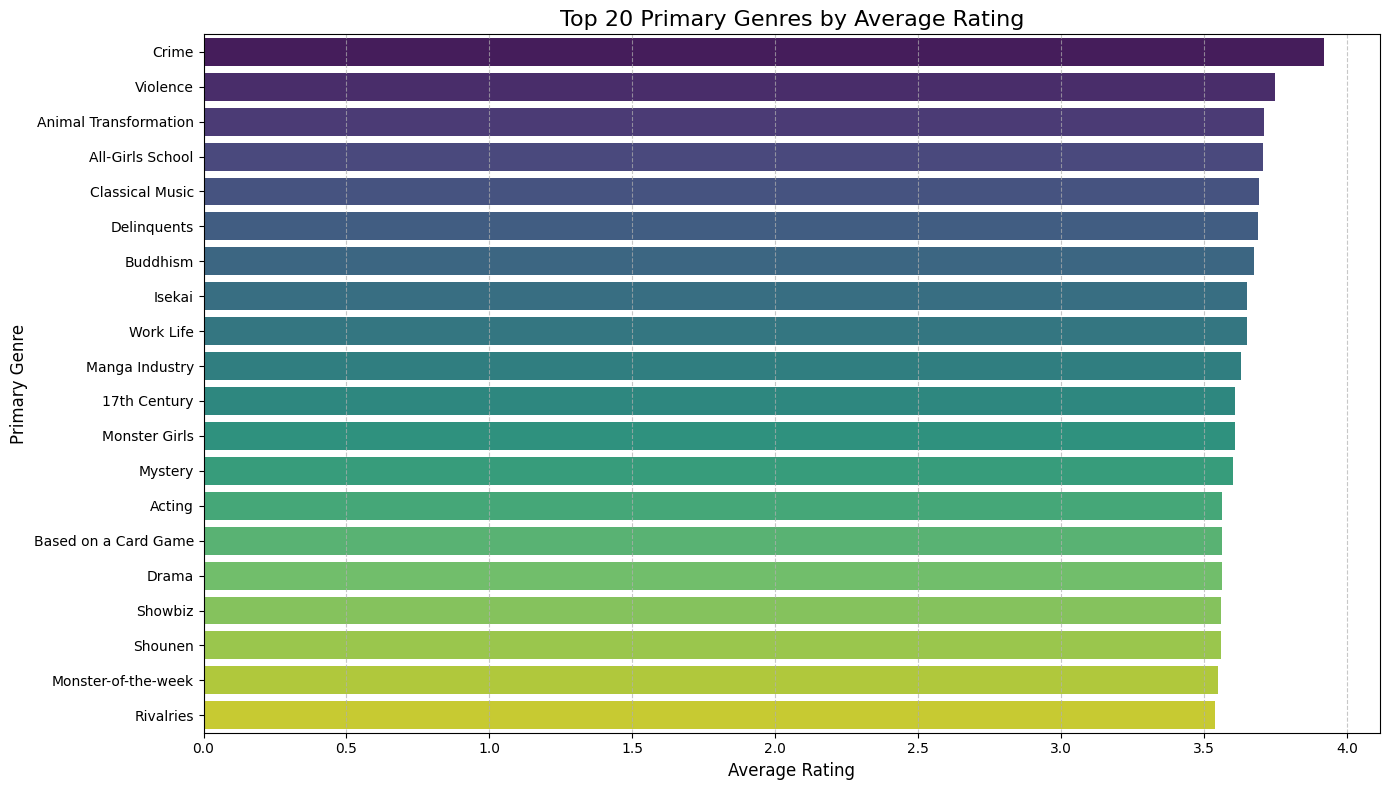

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data: Extract first genre as the primary genre
df_copy = anime_df.copy()
df_copy['Primary_Genre'] = df_copy['Tags'].fillna('').apply(lambda x: x.split(',')[0].strip() if x else 'Unknown')

# Group and calculate average rating, ignoring 'Unknown' or empty genres if desired
grouped_ratings = df_copy.groupby('Primary_Genre')['Rating'].mean().dropna().reset_index()

# Sort by rating to make the plot easier to read
grouped_ratings = grouped_ratings.sort_values(by='Rating', ascending=False)
display(grouped_ratings[:20])

# Plot the top 20 primary genres by average rating
plt.figure(figsize=(14, 8))
sns.barplot(
    x='Rating',
    y='Primary_Genre',
    data=grouped_ratings.head(20),
    palette='viridis'
)

plt.title('Top 20 Primary Genres by Average Rating', fontsize=16)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Primary Genre', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()